/Users/anfelipecb/GitHub/Mansueto/jail-events/.venv/lib/python3.12/site-packages/layoutparser/ocr/tesseract_agent.py:148: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Block 0: BBox=(0, 0, 2550, 3300), Text=''
Block 1: BBox=(676, 22, 1954, 76), Text='   Report of Extraordinary or Unusual Occurrences'
Block 2: BBox=(31, 135, 2387, 183), Text='   Report all extraordinary or unusual occurrences involving detainees in writing within three business days to the Office of Jail &'
Block 3: BBox=(29, 189, 2517, 281), Text='   Detention Standards. When a delay in the written report is unavoidable, make the report by telephone and submit the written report  as soon as possible to:'
Block 4: BBox=(315, 326, 1639, 371), Text='   Office of Jail & Detention Standards Check one: v'
Block 5: BBox=(314, 342, 2360, 544), Text='   County  1301 Concordia Court, P. O. Box19277 C Municipal .  Springfield, Illinois 62794-9277 unicipal (except Chicago)  Telephone: (217) 558-2200, ext. 4212 C1 Chicago Police Department, include'
Block 6: BBox=(317, 549, 2301, 625), Text='   Fax: (217) 558-4004  R.D. Number: DIV11-2021-8744'
Block 7: BBox=(36, 697, 2488, 1216), Text='   Facili

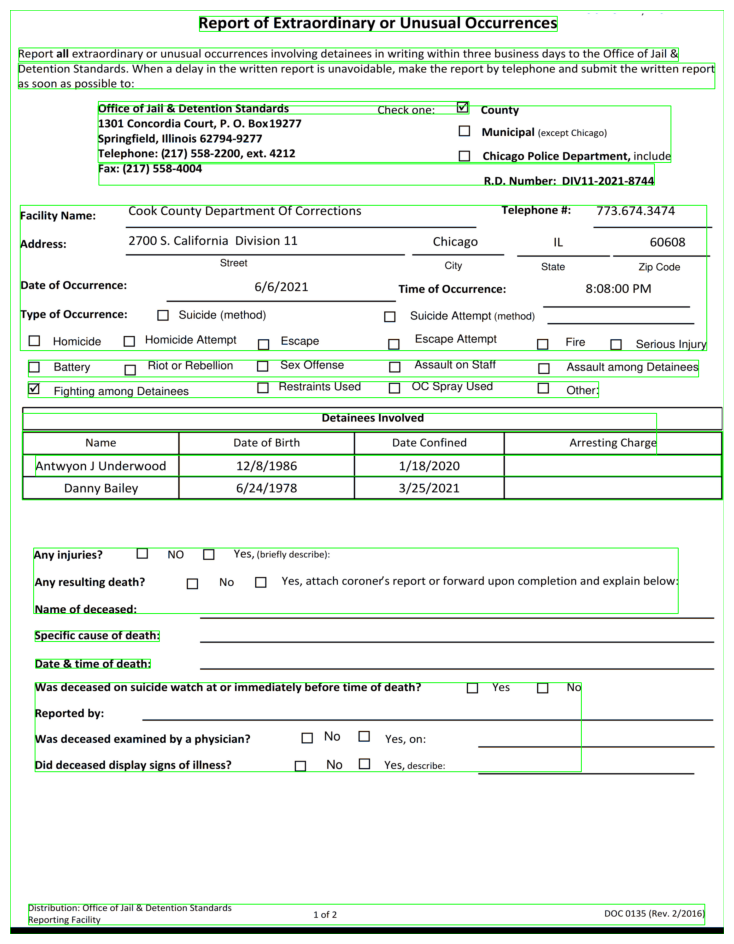

In [11]:
import layoutparser as lp
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from layoutparser.ocr import TesseractFeatureType

# Load and convert image
file = Path('..') / 'data/jails-data/processed/Binder1_p383.png'
image = cv2.imread(str(file))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Initialize Tesseract OCR
ocr_agent = lp.TesseractAgent(languages='eng')

# Detect layout with blocks (not plain text)
layout = ocr_agent.detect(
    image_rgb,
    return_only_text=False,
    agg_output_level=TesseractFeatureType.BLOCK
)


# Process blocks
for idx, item in enumerate(layout):
    block = item.block  # Rectangle object
    text = item.text
    x1, y1, x2, y2 = map(int, block.coordinates)
    print(f"Block {idx}: BBox={block.coordinates}, Text={text!r}")
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Visualize
plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()